<a href="https://colab.research.google.com/github/hess0623977/missing_vakue/blob/main/missing_value_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original dataset: (7043, 50)
MCAR dataset: (7043, 50)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


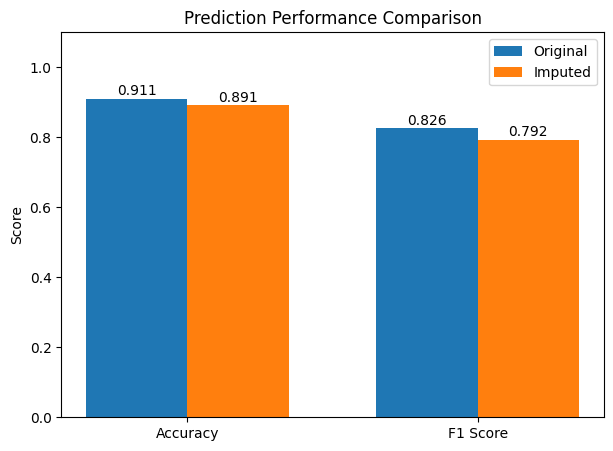

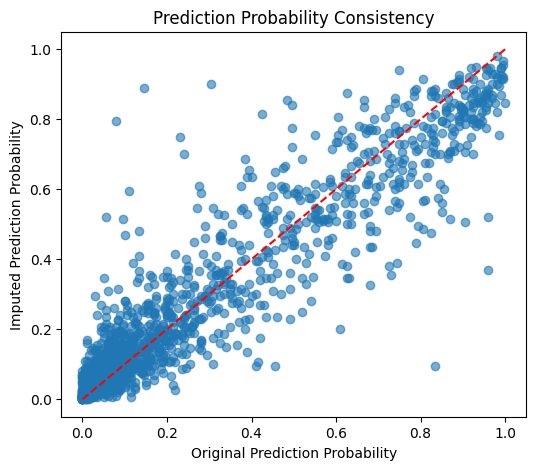

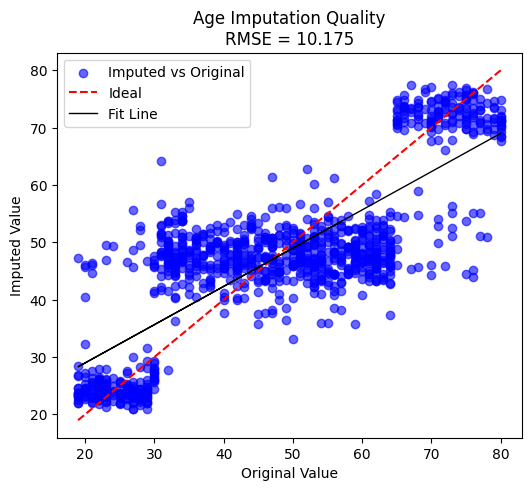

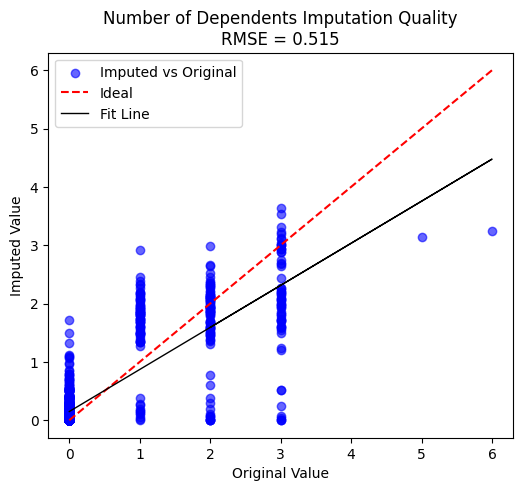

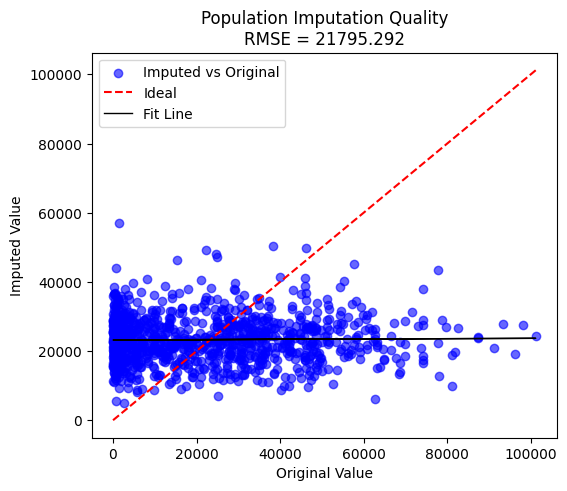

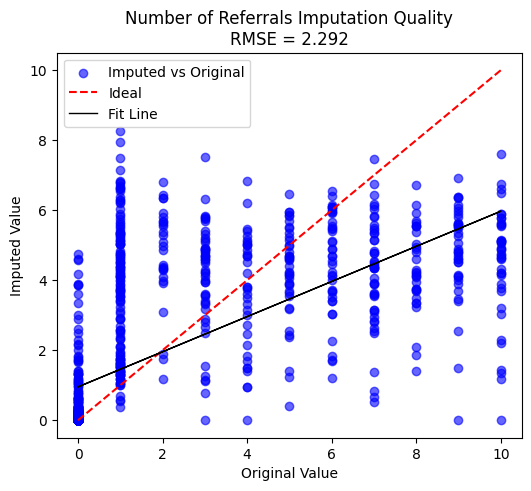

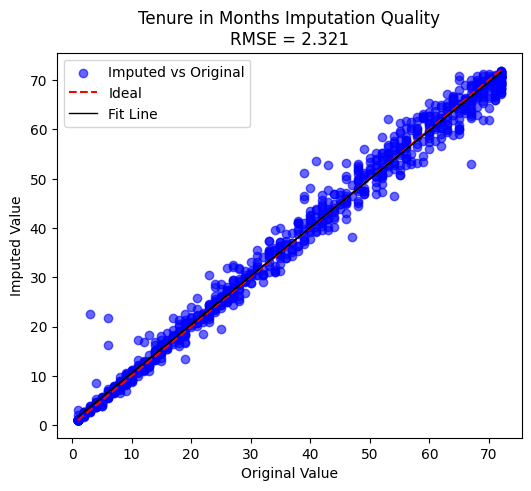

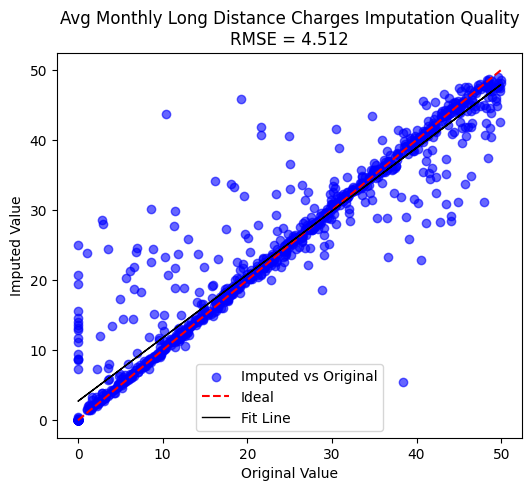

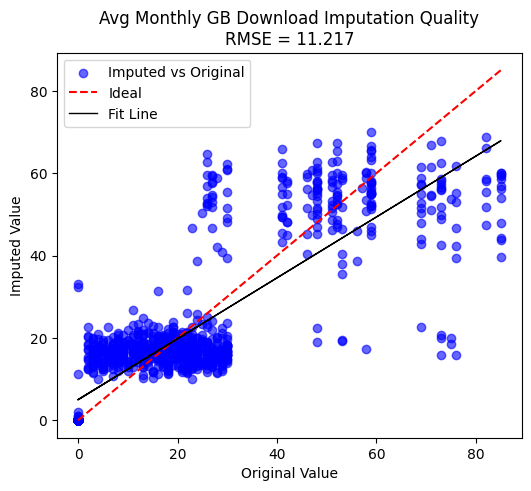

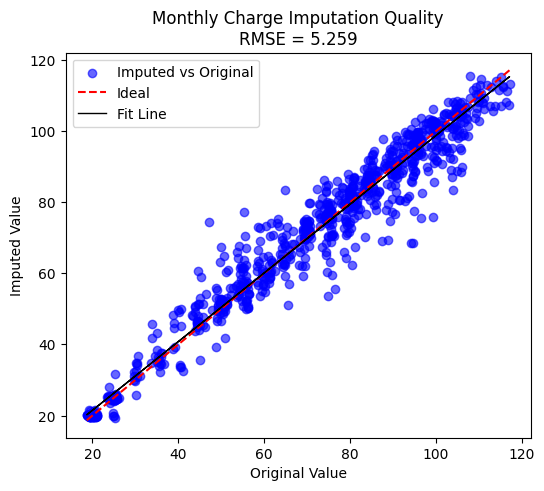

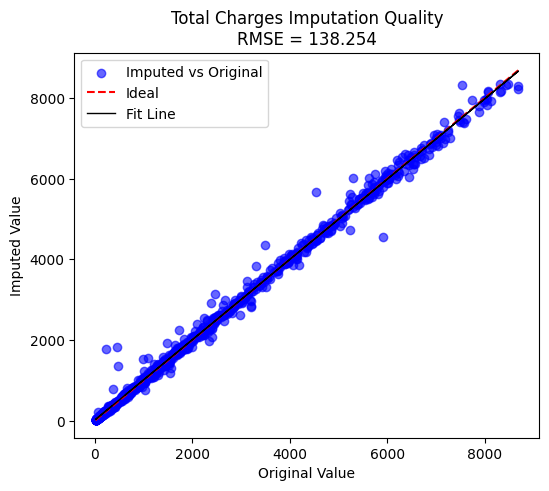

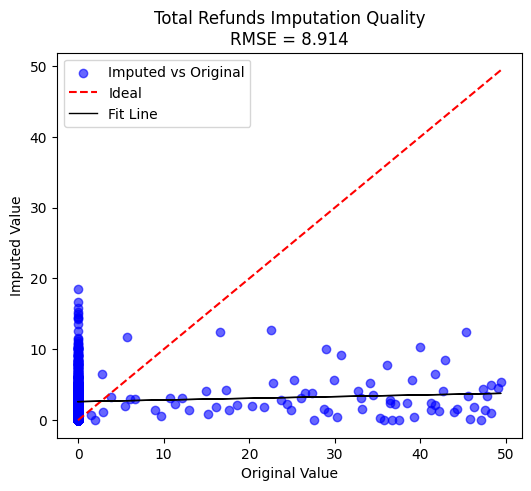

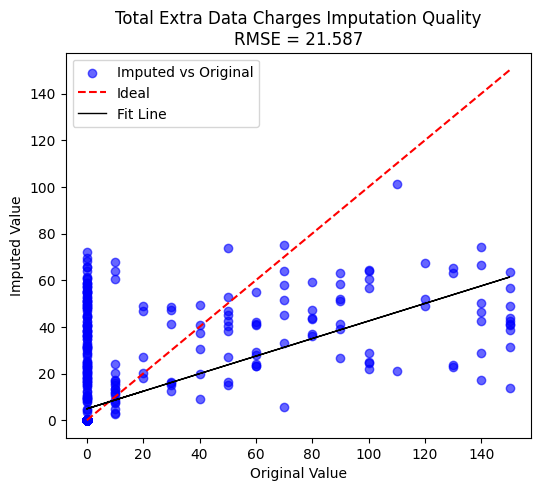

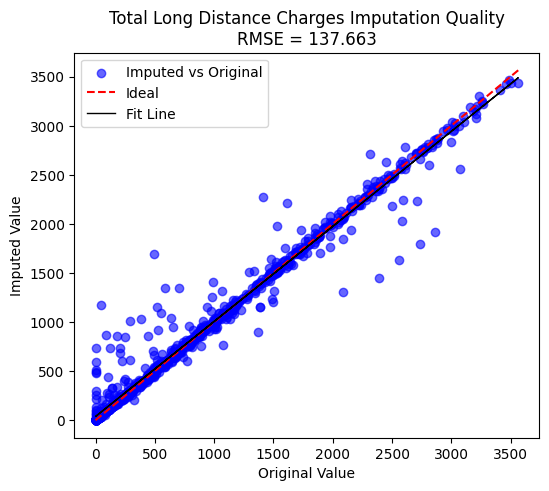

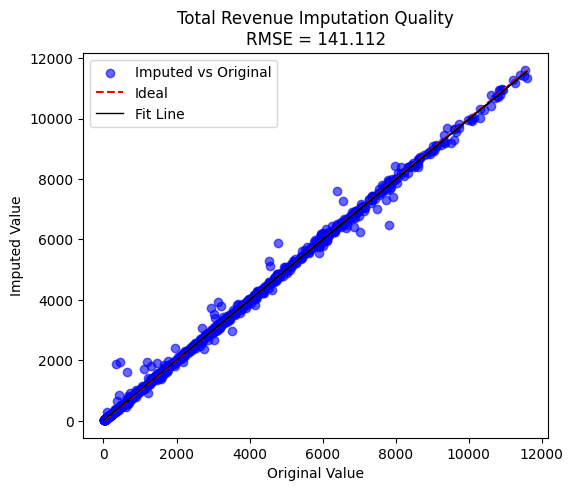

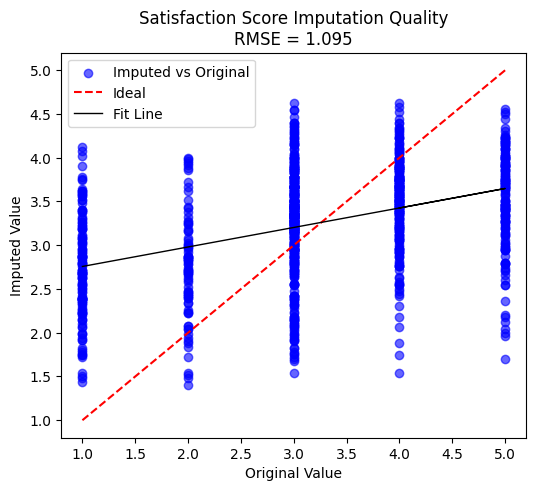

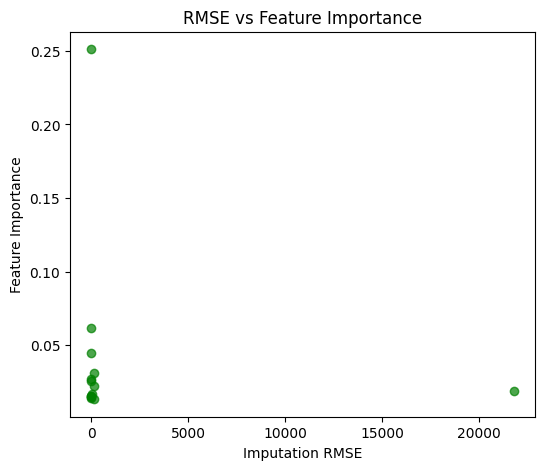

In [7]:
# =========================================================
# Tree-based Imputation vs Original Dataset
# Complete Experimental Pipeline (Fully Improved & Annotated)
# =========================================================

# =========================================================
# 1. 載入套件
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 機器學習工具
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer  # 啟用 IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score

# =========================================================
# 2. 掛載 Google Drive (Colab 使用)
# =========================================================

from google.colab import drive
drive.mount('/content/drive')
data_path = "/content/drive/MyDrive/資料科學與機器學習/literature survey/"

# =========================================================
# 3. 讀取資料
# =========================================================

df_original = pd.read_csv(data_path + "telco.csv")
df_mcar = pd.read_csv(data_path + "telco_mcar.csv")

print("Original dataset:", df_original.shape)
print("MCAR dataset:", df_mcar.shape)

# =========================================================
# 4. 移除不必要欄位
# =========================================================

cols_to_drop = [
    "Customer ID","Country","State","City","Zip Code",
    "Latitude","Longitude","Quarter","Customer Status",
    "Churn Category","Churn Reason","Churn Score","CLTV"
]

df_original.drop(columns=[c for c in cols_to_drop if c in df_original.columns], inplace=True)
df_mcar.drop(columns=[c for c in cols_to_drop if c in df_mcar.columns], inplace=True)

# =========================================================
# 5. 建立 Label
# =========================================================

y_original = df_original["Churn Label"].map({"Yes":1,"No":0})
X_original = df_original.drop(columns=["Churn Label"])

y_mcar = df_mcar["Churn Label"].map({"Yes":1,"No":0})
X_mcar = df_mcar.drop(columns=["Churn Label"])

# 移除 MCAR 資料中 label 為 NaN 的資料
mask = y_mcar.notna()
X_mcar = X_mcar[mask].reset_index(drop=True)
y_mcar = y_mcar[mask].reset_index(drop=True)

# =========================================================
# 6. 數值欄位轉換
# =========================================================

if "Total Charges" in X_original.columns:
    # 將 Total Charges 轉成數值型，非數值會變成 NaN
    X_original["Total Charges"] = pd.to_numeric(X_original["Total Charges"], errors="coerce")
    X_mcar["Total Charges"] = pd.to_numeric(X_mcar["Total Charges"], errors="coerce")

# =========================================================
# 7. One-hot Encoding
# =========================================================

X_original = pd.get_dummies(X_original, drop_first=True)
X_mcar = pd.get_dummies(X_mcar, drop_first=True)

# 確保 MCAR dataset 與原始資料欄位一致
X_mcar = X_mcar.reindex(columns=X_original.columns, fill_value=np.nan)

# =========================================================
# 8. Train / Test Split
# =========================================================

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42
)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mcar, y_mcar, test_size=0.2, random_state=42
)

# =========================================================
# 9. Original Dataset Model
# =========================================================

# Step1: 標準化 (PCA 需要標準化)
scaler_o = StandardScaler()
X_train_o_scaled = scaler_o.fit_transform(X_train_o)
X_test_o_scaled = scaler_o.transform(X_test_o)

# Step2: PCA (保留 95% 變異量)
pca_o = PCA(n_components=0.95)
X_train_o_pca = pca_o.fit_transform(X_train_o_scaled)
X_test_o_pca = pca_o.transform(X_test_o_scaled)

# Step3: Random Forest 建模
model_orig = RandomForestClassifier(n_estimators=200, random_state=42)
model_orig.fit(X_train_o_pca, y_train_o)

y_pred_orig = model_orig.predict(X_test_o_pca)
y_prob_orig = model_orig.predict_proba(X_test_o_pca)[:,1]

acc_orig = accuracy_score(y_test_o, y_pred_orig)
f1_orig = f1_score(y_test_o, y_pred_orig)

# =========================================================
# 10. Tree-based Imputation (IterativeImputer + ExtraTrees)
# =========================================================

imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42
)

X_train_imp = imputer.fit_transform(X_train_m)
X_test_imp = imputer.transform(X_test_m)

X_train_imp = pd.DataFrame(X_train_imp, columns=X_original.columns)
X_test_imp = pd.DataFrame(X_test_imp, columns=X_original.columns)

# =========================================================
# 11. StandardScaler + PCA (Imputed Dataset)
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# =========================================================
# 12. Random Forest (Imputed Dataset)
# =========================================================

model_imp = RandomForestClassifier(n_estimators=200, random_state=42)
model_imp.fit(X_train_pca, y_train_m)

y_pred_imp = model_imp.predict(X_test_pca)
y_prob_imp = model_imp.predict_proba(X_test_pca)[:,1]

acc_imp = accuracy_score(y_test_m, y_pred_imp)
f1_imp = f1_score(y_test_m, y_pred_imp)

# =========================================================
# 13. Performance Comparison Bar Chart
# =========================================================

labels = ["Accuracy","F1 Score"]
original_scores = [acc_orig, f1_orig]
imputed_scores = [acc_imp, f1_imp]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))
bars1 = plt.bar(x-width/2, original_scores, width, label="Original")
bars2 = plt.bar(x+width/2, imputed_scores, width, label="Imputed")

plt.xticks(x, labels)
plt.ylim(0,1.1)
plt.title("Prediction Performance Comparison")
plt.ylabel("Score")
plt.legend()

# 標註每個 bar 的數值
for bar in bars1+bars2:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f"{bar.get_height():.3f}", ha='center')

plt.show()

# =========================================================
# 14. Prediction Probability Consistency
# =========================================================

plt.figure(figsize=(6,5))
plt.scatter(y_prob_orig, y_prob_imp, alpha=0.6)
plt.plot([0,1],[0,1],'r--')  # 理想線
plt.xlabel("Original Prediction Probability")
plt.ylabel("Imputed Prediction Probability")
plt.title("Prediction Probability Consistency")
plt.show()

# =========================================================
# 15. Imputation Quality: 原始 vs 補值 (每個數值欄位一張圖)
# =========================================================

# 選出所有數值欄位 (不含 one-hot 轉換後的 uint8)
numeric_cols = X_original.select_dtypes(include=np.number).columns

# 補值結果
X_mcar_imputed = pd.DataFrame(imputer.transform(X_mcar), columns=X_original.columns)

# 逐欄位繪圖
for col in numeric_cols:

    mask_missing = X_mcar[col].isna()  # 找出 MCAR 原始缺失值位置

    if mask_missing.sum() == 0:
        print(f"{col}: No missing values, skip plotting.")
        continue  # 如果該欄位沒有缺值就跳過

    # 原始缺失位置對應原始值 & 補值後的值
    original_values = X_original.loc[mask_missing, col]
    imputed_values = X_mcar_imputed.loc[mask_missing, col]

    # 計算 RMSE
    rmse = np.sqrt(np.mean((original_values - imputed_values)**2))

    # 畫散佈圖
    plt.figure(figsize=(6,5))
    plt.scatter(original_values, imputed_values, alpha=0.6, color="blue", label="Imputed vs Original")

    # 理想線 (y=x)
    min_val = min(original_values.min(), imputed_values.min())
    max_val = max(original_values.max(), imputed_values.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal")

    # 趨勢線 (Linear Fit)
    m, b = np.polyfit(original_values.fillna(original_values.mean()), imputed_values, 1)
    plt.plot(original_values, m*original_values+b, color="black", linewidth=1, label="Fit Line")

    # 標題 + 標籤
    plt.title(f"{col} Imputation Quality\nRMSE = {rmse:.3f}")
    plt.xlabel("Original Value")
    plt.ylabel("Imputed Value")
    plt.legend()
    plt.show()

# =========================================================
# 16. RMSE vs Feature Importance
# =========================================================

# 取前幾個數值欄位對應的 feature importance
feature_importance = model_orig.feature_importances_[:len(numeric_cols)]
rmse_list = [np.sqrt(np.mean((X_original.loc[X_mcar[col].isna(), col] - X_mcar_imputed.loc[X_mcar[col].isna(), col])**2))
             if X_mcar[col].isna().sum()>0 else 0 for col in numeric_cols]

plt.figure(figsize=(6,5))
plt.scatter(rmse_list, feature_importance, color="green", alpha=0.7)
plt.xlabel("Imputation RMSE")
plt.ylabel("Feature Importance")
plt.title("RMSE vs Feature Importance")
plt.show()